In [7]:

import zipfile
import shutil
import tempfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from skimage.color import label2rgb

from data_setup_v3 import (
    download,
    preprocess_raw,
    segment,
    pad_to_square,
    resize_patch
)

mpl.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "figure.dpi": 300,
    "savefig.dpi": 600,
    "axes.titlesize": 12,
    "axes.labelsize": 11
})

FIG_DIR = Path("./figures")
FIG_DIR.mkdir(exist_ok=True)

In [2]:

from tqdm import tqdm

download()

ZIP_FILE = Path("./dataset/rice_hsi.zip")
zf = zipfile.ZipFile(ZIP_FILE, "r")

# Load wavelengths
wl = None
for m in zf.infolist():
    if m.filename.endswith("wavelengths.csv"):
        with tempfile.TemporaryDirectory() as tmp:
            tmp = Path(tmp)
            with zf.open(m) as src, open(tmp/"wl.csv","wb") as dst:
                shutil.copyfileobj(src, dst)
            wl = pd.read_csv(tmp/"wl.csv")["Wavelength (nm)"].values
        break

# Find ONE valid cube
sample = None
for m in zf.infolist():
    if m.filename.lower().endswith(".hdr") and not m.filename.lower().endswith("black.hdr"):
        parts = Path(m.filename).parts
        session = next((p for p in parts if p.startswith("Data-VIS")), None)
        if session:
            sample = (session, m)
            break

assert sample is not None

session, hdr_member = sample

with tempfile.TemporaryDirectory() as tmp:
    tmp = Path(tmp)

    files = [m for m in zf.infolist() if session in m.filename]

    stem = hdr_member.filename[:-4]

    data_member = next(
        m for m in files
        if m.filename.startswith(stem) and not m.filename.endswith(".hdr")
    )

    black_hdr = next(
        m for m in files
        if m.filename.lower().endswith("black.hdr")
    )

    black_stem = black_hdr.filename[:-4]
    black_data = next(
        m for m in files
        if m.filename.startswith(black_stem) and not m.filename.endswith(".hdr")
    )

    for m in [hdr_member, data_member, black_hdr, black_data]:
        out = tmp / m.filename
        out.parent.mkdir(parents=True, exist_ok=True)
        with zf.open(m) as src, open(out, "wb") as dst:
            shutil.copyfileobj(src, dst)

    cube = preprocess_raw(tmp / hdr_member.filename,
                          tmp / black_hdr.filename)

    labeled, regions = segment(cube, wl)

    SAMPLE_DATA = (cube, labeled, regions, wl)

Zip exists. Skipping download.


/Users/jerlshin/FieldOfInterest/ResearchWork/HSI_RGB_seeds/Code/data_setup_v3.py:104: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  binary = remove_small_objects(binary, 150)


### Generate Visual Components

In [3]:
# ============================================================
# GENERATE VISUAL COMPONENTS
# ============================================================

cube, labeled, regions, wl = SAMPLE_DATA

# --- Visible mean image ---
vis_mask = (wl > 450) & (wl < 700)
vis_img = cube[:, :, vis_mask].mean(axis=2)

# --- Binary mask ---
binary = labeled > 0

# --- Colored labels ---
label_rgb = label2rgb(labeled, bg_label=0)

# --- Extract patches (3 samples) ---
patches = []
for r in regions[:3]:
    r0, c0, r1, c1 = r.bbox
    p = cube[r0:r1, c0:c1, :].copy()

    mask = (labeled[r0:r1, c0:c1] == r.label)
    p *= mask[..., None]

    p = pad_to_square(p)
    p = resize_patch(p)

    # Convert to visible representation
    p_vis = p[:, :, vis_mask].mean(axis=2)
    patches.append(p_vis)

In [8]:
# ============================================================
# SAVE EACH COMPONENT SEPARATELY (PUBLICATION QUALITY)
# ============================================================

import matplotlib.pyplot as plt
import matplotlib as mpl

# --- Publication settings ---
mpl.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "figure.dpi": 300,
    "savefig.dpi": 600,
})
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

def normalize(img):
    img = img.astype(np.float32)
    return (img - img.min()) / (img.max() - img.min() + 1e-8)

# Normalize images for consistent appearance
vis_norm = normalize(vis_img)

# ============================================================
# 1. RAW HSI (VISIBLE MEAN)
# ============================================================

plt.figure(figsize=(4, 4))
plt.imshow(vis_norm, cmap='gray')
plt.axis('off')
plt.tight_layout()

plt.savefig(FIG_DIR / "raw_hsi_visible.png", bbox_inches='tight', pad_inches=0)
plt.close()


# ============================================================
# 2. OTSU BINARY MASK
# ============================================================

plt.figure(figsize=(4, 4))
plt.imshow(binary, cmap='gray')
plt.axis('off')
plt.tight_layout()

plt.savefig(FIG_DIR / "otsu_mask.png", bbox_inches='tight', pad_inches=0)
plt.close()


# ============================================================
# 3. LABELED COMPONENTS
# ============================================================

plt.figure(figsize=(4, 4))
plt.imshow(label_rgb)
plt.axis('off')
plt.tight_layout()

plt.savefig(FIG_DIR / "labeled_components.png", bbox_inches='tight', pad_inches=0)
plt.close()


# ============================================================
# 4. PATCHES (SAVE INDIVIDUALLY)
# ============================================================

for i, p in enumerate(patches):
    p_norm = normalize(p)

    plt.figure(figsize=(3, 3))
    plt.imshow(p_norm, cmap='gray')
    plt.axis('off')
    plt.tight_layout()

    plt.savefig(FIG_DIR / f"patch_{i+1}.png", bbox_inches='tight', pad_inches=0)
    plt.close()

print(f"Saved all figures to → {FIG_DIR}")

Saved all figures to → figures


In [9]:
# ============================================================
# CREATE FIGURE (PIPELINE COMPONENTS)
# ============================================================

fig = plt.figure(figsize=(12, 6))

gs = fig.add_gridspec(2, 4, height_ratios=[1, 1.2])

# --- Top row ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.imshow(vis_img, cmap='gray')
ax1.set_title("Raw HSI (Visible Mean)")
ax1.axis('off')

ax2 = fig.add_subplot(gs[0, 1])
ax2.imshow(binary, cmap='gray')
ax2.set_title("Otsu Binary Mask")
ax2.axis('off')

ax3 = fig.add_subplot(gs[0, 2])
ax3.imshow(label_rgb)
ax3.set_title("Labeled Components")
ax3.axis('off')

# --- Bottom row (patches) ---
for i, p in enumerate(patches):
    ax = fig.add_subplot(gs[1, i])
    ax.imshow(p, cmap='gray')
    ax.set_title(f"Patch {i+1}")
    ax.axis('off')

# --- Empty space (for alignment) ---
ax_empty = fig.add_subplot(gs[1, 3])
ax_empty.axis('off')

plt.tight_layout()

# Save high-quality figure
save_path = FIG_DIR / "pipeline_preprocessing.png"
plt.savefig(save_path, bbox_inches='tight')
plt.close()

print(f"Saved → {save_path}")

Saved → figures/pipeline_preprocessing.png


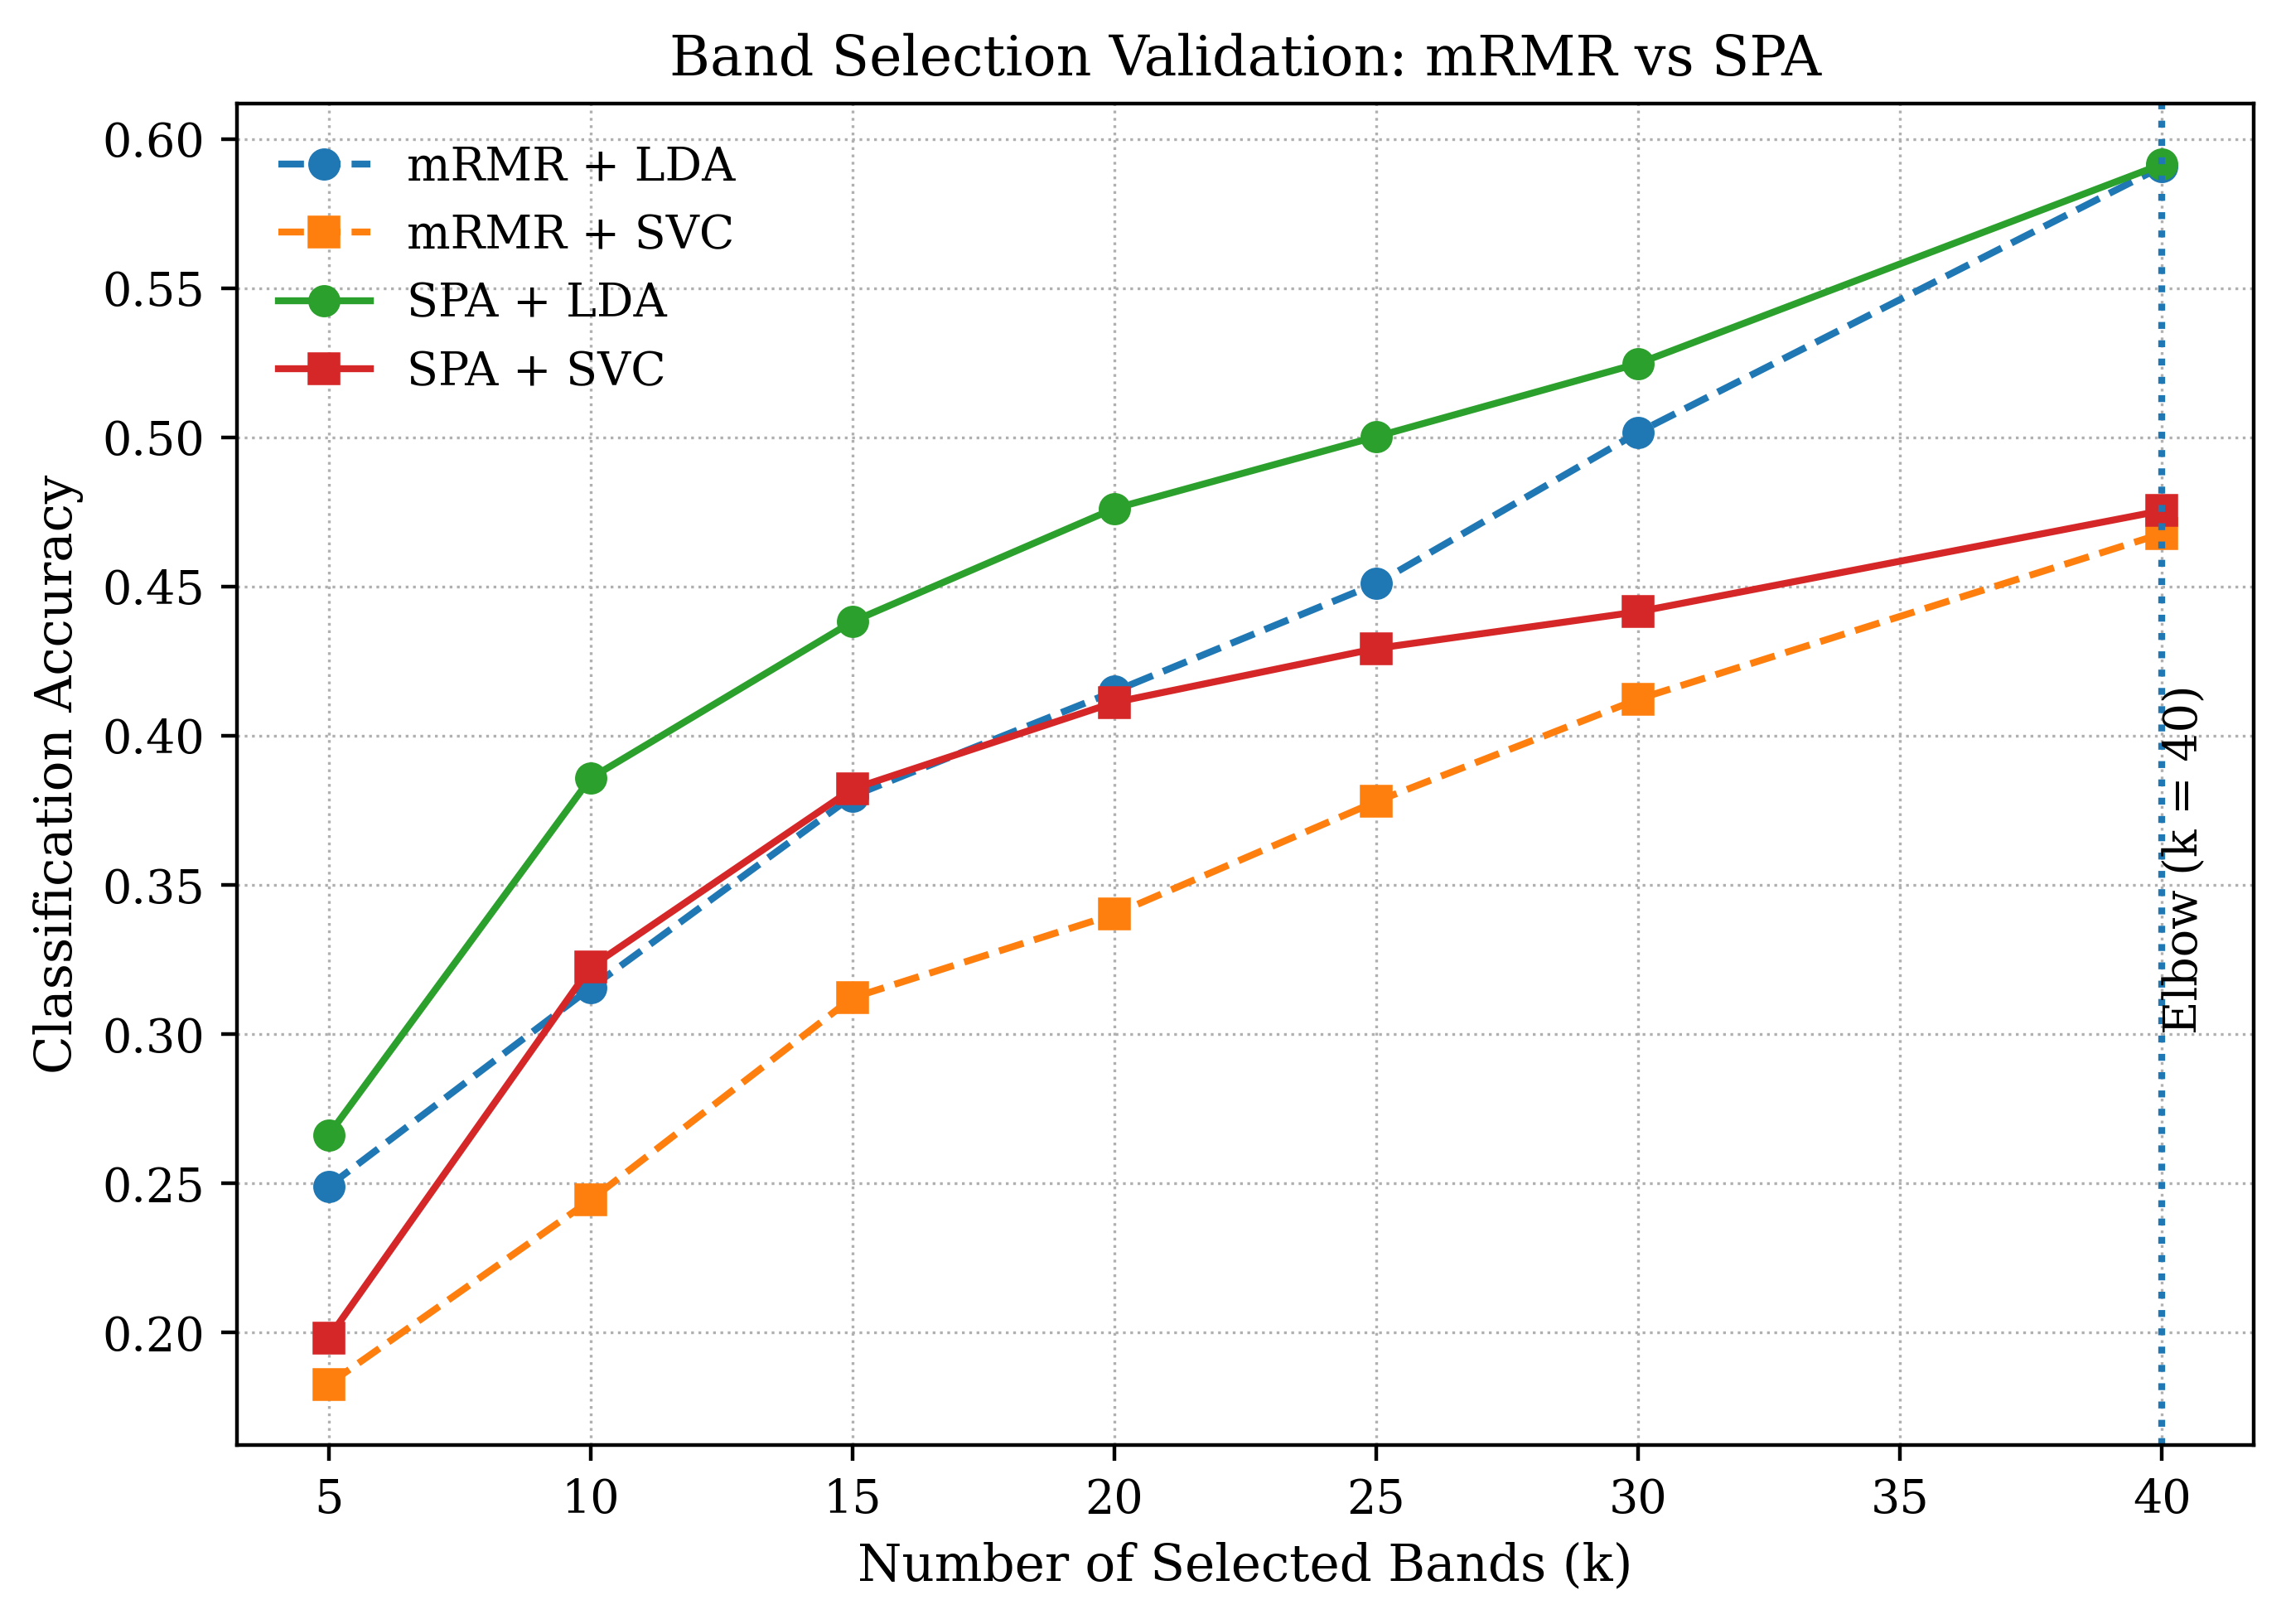

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# DATA (from your experiment)
# -------------------------------
k = np.array([5, 10, 15, 20, 25, 30, 40])

mrmr_lda = np.array([0.2490, 0.3155, 0.3798, 0.4149, 0.4510, 0.5017, 0.5908])
mrmr_svc = np.array([0.1827, 0.2444, 0.3122, 0.3402, 0.3780, 0.4123, 0.4678])

spa_lda  = np.array([0.2662, 0.3858, 0.4383, 0.4762, 0.5003, 0.5248, 0.5916])
spa_svc  = np.array([0.1982, 0.3225, 0.3822, 0.4112, 0.4293, 0.4416, 0.4755])

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "figure.dpi": 400
})

# -------------------------------
# PLOT
# -------------------------------
plt.figure(figsize=(7, 5))

# mRMR curves
plt.plot(k, mrmr_lda, linestyle='--', marker='o', label='mRMR + LDA')
plt.plot(k, mrmr_svc, linestyle='--', marker='s', label='mRMR + SVC')

# SPA curves (highlighted)
plt.plot(k, spa_lda, linewidth=1.5, marker='o', label='SPA + LDA')
plt.plot(k, spa_svc, linewidth=1.5, marker='s', label='SPA + SVC')

# -------------------------------
# ELBOW MARK (k = 40)
# -------------------------------
plt.axvline(x=40, linestyle=':', linewidth=1.5)
plt.text(40, 0.30, 'Elbow (k = 40)', rotation=90, va='bottom')

# -------------------------------
# LABELS
# -------------------------------
plt.xlabel('Number of Selected Bands (k)', fontsize=11)
plt.ylabel('Classification Accuracy', fontsize=11)

plt.title('Band Selection Validation: mRMR vs SPA', fontsize=12)

plt.legend(frameon=False)
plt.grid(True, linestyle=':', linewidth=0.6)

plt.tight_layout()

# -------------------------------
# SAVE (IMPORTANT for paper)
# -------------------------------
plt.savefig('band_selection_curve.png', dpi=600)
plt.savefig('band_selection_curve.pdf')

plt.show()

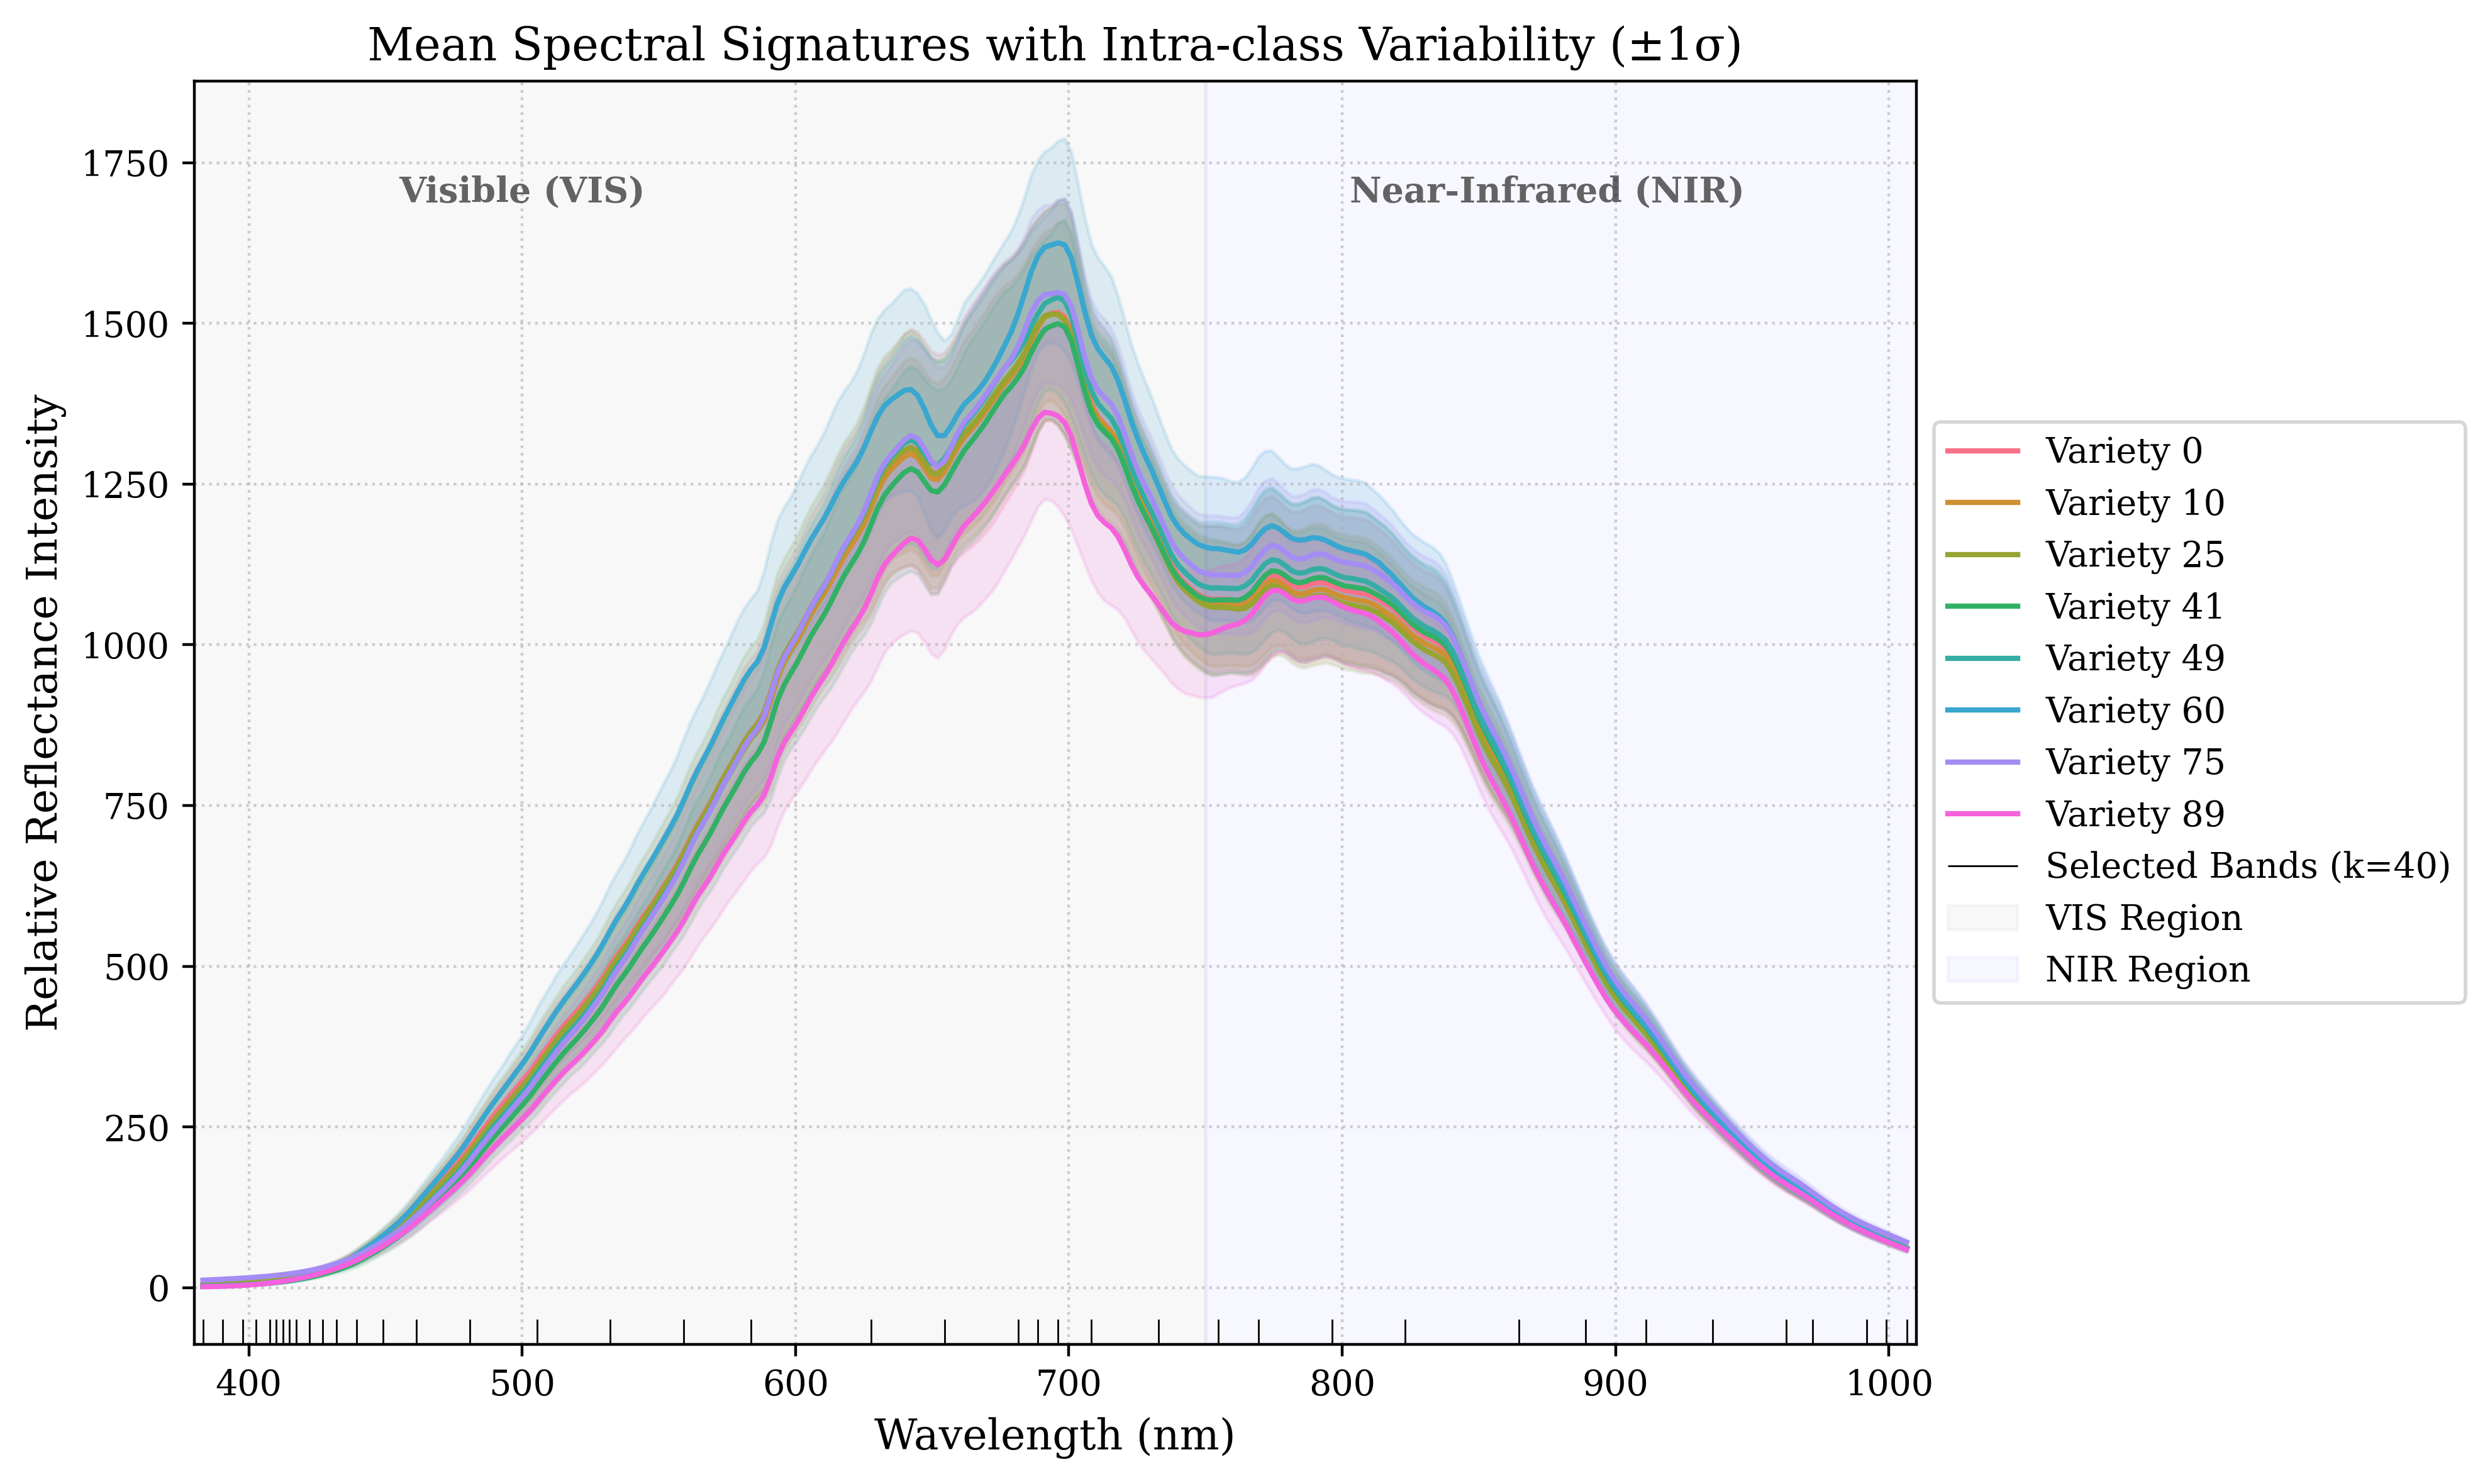

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# 1. LOAD DATA & METADATA
# -----------------------------
patches = np.load("./dataset/patches.npy", mmap_mode='r')
labels  = np.load("./dataset/labels.npy")
wl_df   = pd.read_csv("./dataset/wavelengths.csv")
wavelengths = wl_df.iloc[:, -1].values  # Use the last column

# The 40 wavelengths selected by your SPA algorithm (from your report)
selected_wl = [
    383.2, 390.5, 397.8, 402.7, 407.6, 410.0, 412.5, 414.9, 417.4, 422.2,
    427.1, 432.0, 439.4, 449.1, 461.4, 480.9, 505.4, 532.2, 559.1, 583.6,
    627.6, 654.5, 681.4, 688.7, 696.0, 708.2, 732.7, 754.7, 769.4, 796.2,
    823.1, 864.7, 889.1, 911.1, 935.6, 962.5, 972.2, 991.8, 999.1, 1006.5
]

# -----------------------------
# 2. PARAMETERS & SELECTION
# -----------------------------
# Selecting a mix of "easy" and "hard" classes (e.g., 41 and 49) to show overlap
selected_classes = [0, 10, 25, 41, 49, 60, 75, 89] 
colors = sns.color_palette("husl", len(selected_classes))

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "figure.dpi": 400
})

# -----------------------------
# 3. COMPUTE MEAN & STD
# -----------------------------
plt.figure(figsize=(10, 6))

for idx, c in enumerate(selected_classes):
    class_indices = np.where(labels == c)[0][:50] # Subset for efficiency
    spectra_list = []

    for i in class_indices:
        flat = patches[i].reshape(patches[i].shape[0], -1)
        mask = (np.abs(flat).sum(axis=0) > 1e-5)
        if mask.sum() > 0:
            spectra_list.append(flat[:, mask].mean(axis=1))
    
    spectra_array = np.stack(spectra_list)
    mu = spectra_array.mean(axis=0)
    sigma = spectra_array.std(axis=0)

    # Plot Mean Line
    plt.plot(wavelengths, mu, color=colors[idx], linewidth=1.5, label=f'Variety {c}')
    # Plot Standard Deviation Shade (Intra-class variability)
    plt.fill_between(wavelengths, mu - sigma, mu + sigma, color=colors[idx], alpha=0.15)

# -----------------------------
# 4. ENHANCED FEATURES (Scientific)
# -----------------------------
# A. Highlight the 40 SPA-selected bands as vertical ticks
plt.vlines(selected_wl, ymin=-0.02, ymax=0.02, colors='black', 
           linewidth=0.5, transform=plt.gca().get_xaxis_transform(), 
           label="Selected Bands (k=40)")

# B. Label Spectral Regions
plt.axvspan(380, 750, color='gray', alpha=0.05, label="VIS Region")
plt.axvspan(750, 1010, color='blue', alpha=0.03, label="NIR Region")

# C. Annotations for clarity
plt.text(500, plt.ylim()[1]*0.9, 'Visible (VIS)', horizontalalignment='center', fontweight='bold', alpha=0.6)
plt.text(875, plt.ylim()[1]*0.9, 'Near-Infrared (NIR)', horizontalalignment='center', fontweight='bold', alpha=0.6)

# -----------------------------
# 5. LABELS & EXPORT
# -----------------------------
plt.xlabel("Wavelength (nm)")
plt.ylabel("Relative Reflectance Intensity")
plt.title("Mean Spectral Signatures with Intra-class Variability (±1σ)")

plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=True, ncol=1)
plt.xlim(380, 1010)
plt.tight_layout()

# Save in high-quality formats required by journals
plt.savefig("spectral_signatures.png", dpi=600, bbox_inches='tight')

plt.show()